# 中国进出口数据可视化

本notebook用于可视化中国进出口数据，生成各种图表用于分析和分享。

主要可视化内容：
1. 进出口总额时间趋势
2. 主要贸易伙伴分析
3. 主要商品类别分析
4. 进出口对比分析

In [1]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 设置绘图风格
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# 设置数据路径
PROCESSED_DATA_PATH = '../data/processed'
DASHBOARD_PATH = '../dashboards'

# 创建dashboards目录（如果不存在）
Path(DASHBOARD_PATH).mkdir(parents=True, exist_ok=True)

print("库导入完成！")
print(f"图表将保存到：{DASHBOARD_PATH}")

库导入完成！
图表将保存到：../dashboards


In [2]:
# 读取处理后的数据
print("=== 读取数据 ===")
import_data = pd.read_csv(os.path.join(PROCESSED_DATA_PATH, 'processed_import_data.csv'))
export_data = pd.read_csv(os.path.join(PROCESSED_DATA_PATH, 'processed_export_data.csv'))

# 转换日期列为datetime类型
import_data['date'] = pd.to_datetime(import_data['date'])
export_data['date'] = pd.to_datetime(export_data['date'])

print(f"Import数据形状：{import_data.shape}")
print(f"Export数据形状：{export_data.shape}")

# 显示数据摘要
print("\nImport数据概览：")
print(import_data.head())
print("\nExport数据概览：")
print(export_data.head())

=== 读取数据 ===
Import数据形状：(1783, 11)
Export数据形状：(1164, 11)

Import数据概览：
        date  Commodity code                             Commodity  \
0 2024-01-31         9011100  Coffee, not roasted or decaffeinated   
1 2024-01-31         9011100  Coffee, not roasted or decaffeinated   
2 2024-01-31         9011100  Coffee, not roasted or decaffeinated   
3 2024-01-31         9011100  Coffee, not roasted or decaffeinated   
4 2024-01-31         9011100  Coffee, not roasted or decaffeinated   

   Trading partner code Trading partner Quantity      Unit  \
0                   111           India        1  Kilogram   
1                   112       Indonesia   514110  Kilogram   
2                   122        Malaysia        0  Kilogram   
3                   141        Viet Nam  2505710  Kilogram   
4                   217        Ethiopia  1826533  Kilogram   

   Supplementary Quantity Supplementary Unit  US dollar            source_file  
0                     0.0                  ?         47

## 1. 进出口总额时间趋势

图表已保存到：../dashboards/trade_trend_over_time.png


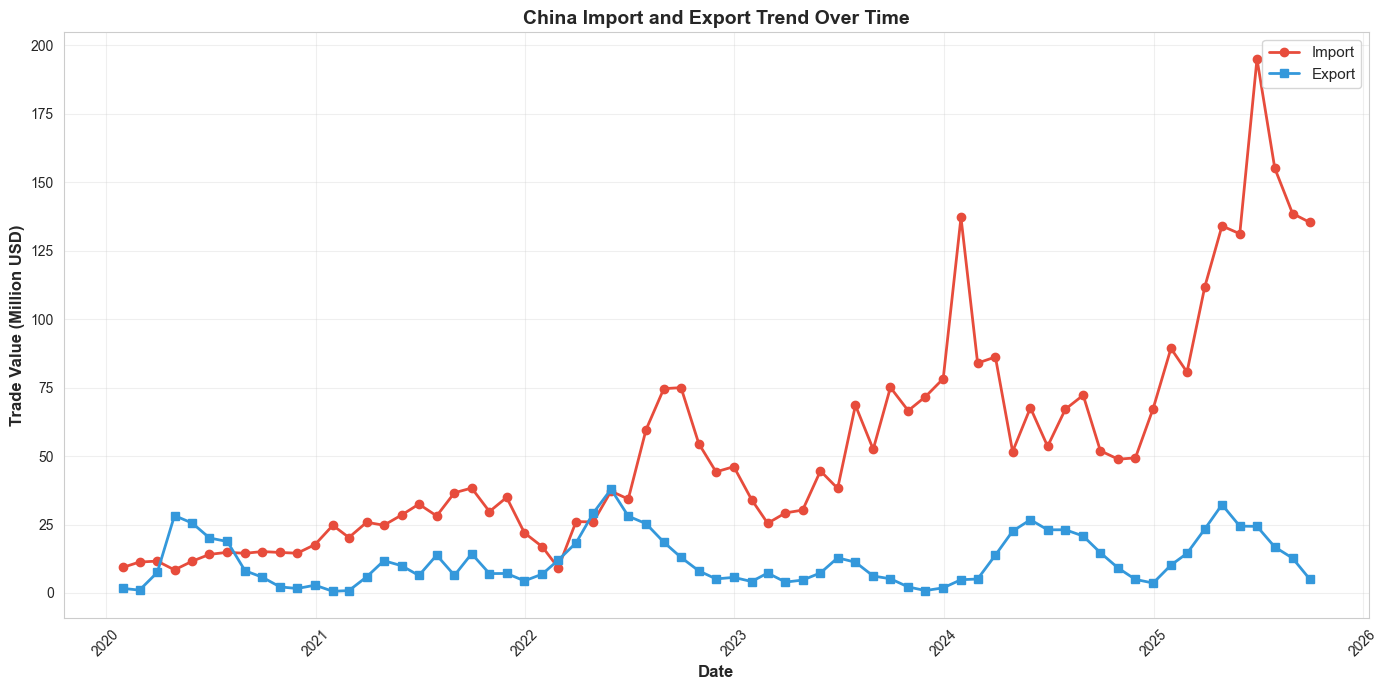

In [3]:
# 准备时间序列数据 - 将US dollar列转换为数值
def clean_dollar_value(value):
    """清理美元金额数据"""
    if pd.isna(value):
        return 0
    if isinstance(value, str):
        # 移除逗号和其他非数字字符
        value = value.replace(',', '').replace('$', '').strip()
        try:
            return float(value)
        except:
            return 0
    return float(value)

# 清理数据
import_data['US dollar_clean'] = import_data['US dollar'].apply(clean_dollar_value)
export_data['US dollar_clean'] = export_data['US dollar'].apply(clean_dollar_value)

# 按月份汇总
import_monthly = import_data.groupby('date')['US dollar_clean'].sum().reset_index()
export_monthly = export_data.groupby('date')['US dollar_clean'].sum().reset_index()

# 创建图表
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(import_monthly['date'], import_monthly['US dollar_clean']/1e6, 
        marker='o', linewidth=2, label='Import', color='#e74c3c')
ax.plot(export_monthly['date'], export_monthly['US dollar_clean']/1e6, 
        marker='s', linewidth=2, label='Export', color='#3498db')

ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Trade Value (Million USD)', fontsize=12, fontweight='bold')
ax.set_title('China Import and Export Trend Over Time', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()

# 保存图表
output_path = os.path.join(DASHBOARD_PATH, 'trade_trend_over_time.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"图表已保存到：{output_path}")

plt.show()

## 2. 主要贸易伙伴分析 - Top 10

图表已保存到：../dashboards/top_trading_partners.png


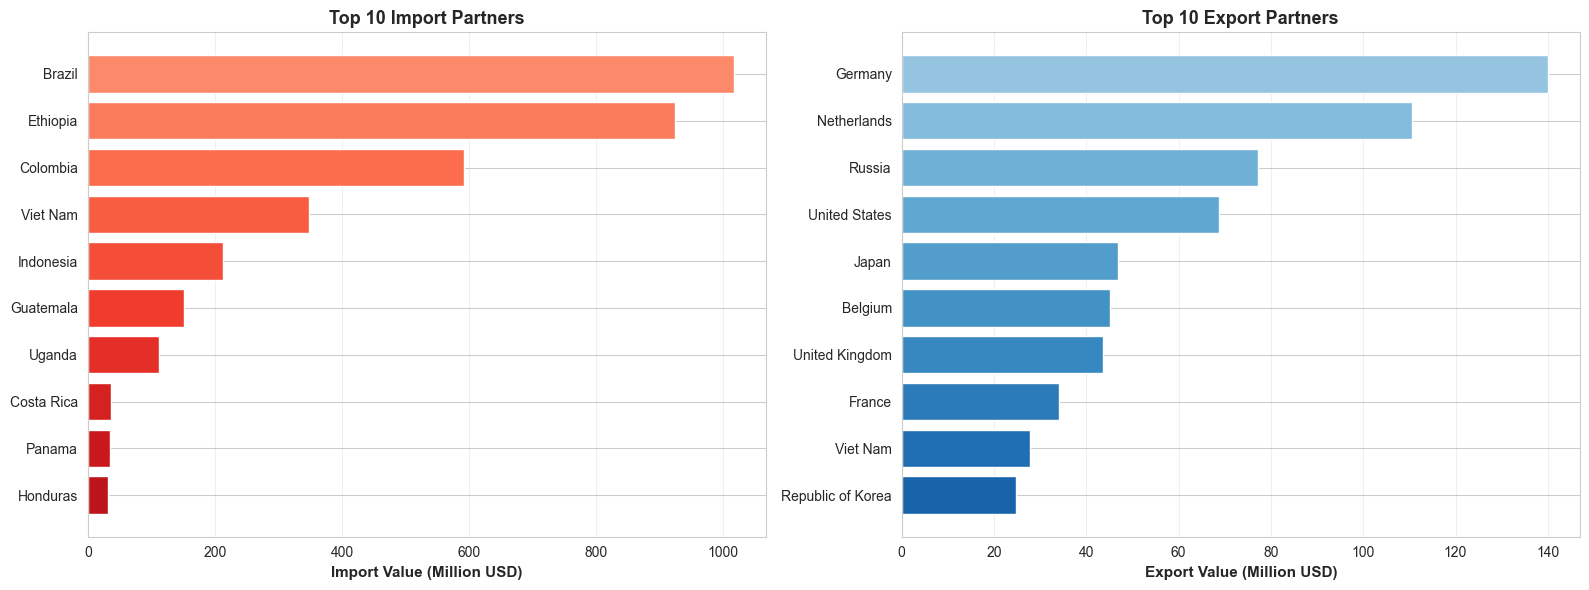

In [4]:
# 计算主要贸易伙伴
top_import_partners = import_data.groupby('Trading partner')['US dollar_clean'].sum().sort_values(ascending=False).head(10)
top_export_partners = export_data.groupby('Trading partner')['US dollar_clean'].sum().sort_values(ascending=False).head(10)

# 创建双子图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Import partners
colors_import = plt.cm.Reds(np.linspace(0.4, 0.8, 10))
ax1.barh(range(10), top_import_partners.values/1e6, color=colors_import)
ax1.set_yticks(range(10))
ax1.set_yticklabels(top_import_partners.index, fontsize=10)
ax1.set_xlabel('Import Value (Million USD)', fontsize=11, fontweight='bold')
ax1.set_title('Top 10 Import Partners', fontsize=13, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# Export partners
colors_export = plt.cm.Blues(np.linspace(0.4, 0.8, 10))
ax2.barh(range(10), top_export_partners.values/1e6, color=colors_export)
ax2.set_yticks(range(10))
ax2.set_yticklabels(top_export_partners.index, fontsize=10)
ax2.set_xlabel('Export Value (Million USD)', fontsize=11, fontweight='bold')
ax2.set_title('Top 10 Export Partners', fontsize=13, fontweight='bold')
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()

# 保存图表
output_path = os.path.join(DASHBOARD_PATH, 'top_trading_partners.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"图表已保存到：{output_path}")

plt.show()

## 3. 主要商品类别分析 - Top 15

图表已保存到：../dashboards/top_commodities.png


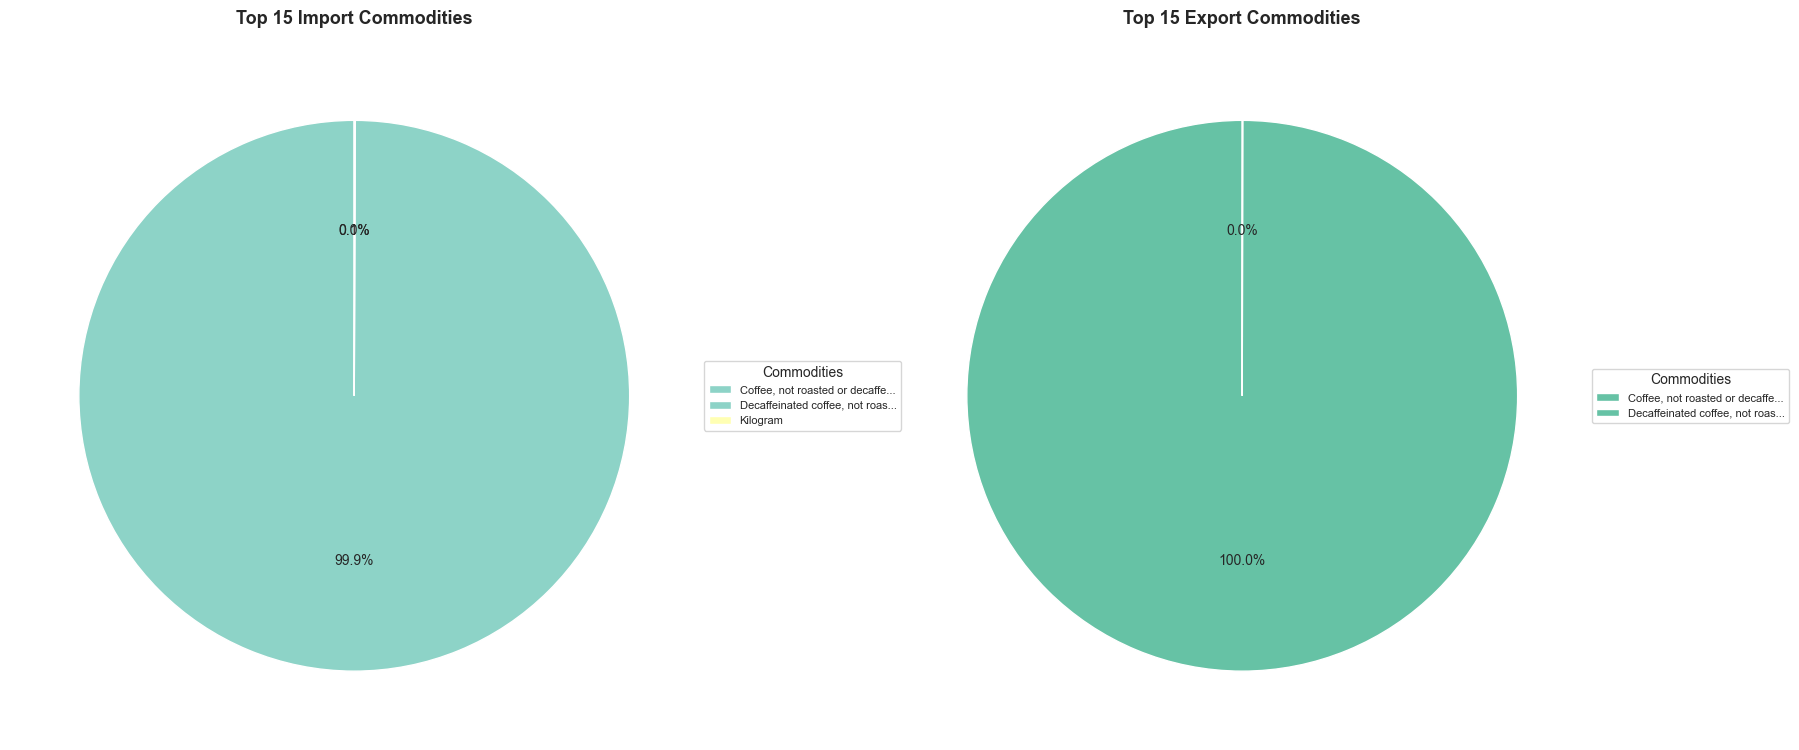

In [5]:
# 计算主要商品类别
top_import_commodities = import_data.groupby('Commodity')['US dollar_clean'].sum().sort_values(ascending=False).head(15)
top_export_commodities = export_data.groupby('Commodity')['US dollar_clean'].sum().sort_values(ascending=False).head(15)

# 创建饼图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Import commodities pie chart
colors1 = plt.cm.Set3(np.linspace(0, 1, 15))
wedges1, texts1, autotexts1 = ax1.pie(top_import_commodities.values, 
                                        labels=None,
                                        autopct='%1.1f%%',
                                        colors=colors1,
                                        startangle=90)
ax1.set_title('Top 15 Import Commodities', fontsize=13, fontweight='bold', pad=20)

# 添加图例
ax1.legend(wedges1, [f"{label[:30]}..." if len(label) > 30 else label 
                     for label in top_import_commodities.index],
          title="Commodities",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1),
          fontsize=8)

# Export commodities pie chart
colors2 = plt.cm.Set2(np.linspace(0, 1, 15))
wedges2, texts2, autotexts2 = ax2.pie(top_export_commodities.values,
                                        labels=None,
                                        autopct='%1.1f%%',
                                        colors=colors2,
                                        startangle=90)
ax2.set_title('Top 15 Export Commodities', fontsize=13, fontweight='bold', pad=20)

# 添加图例
ax2.legend(wedges2, [f"{label[:30]}..." if len(label) > 30 else label 
                     for label in top_export_commodities.index],
          title="Commodities",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1),
          fontsize=8)

plt.tight_layout()

# 保存图表
output_path = os.path.join(DASHBOARD_PATH, 'top_commodities.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"图表已保存到：{output_path}")

plt.show()

## 4. 进出口贸易平衡分析

图表已保存到：../dashboards/trade_balance.png


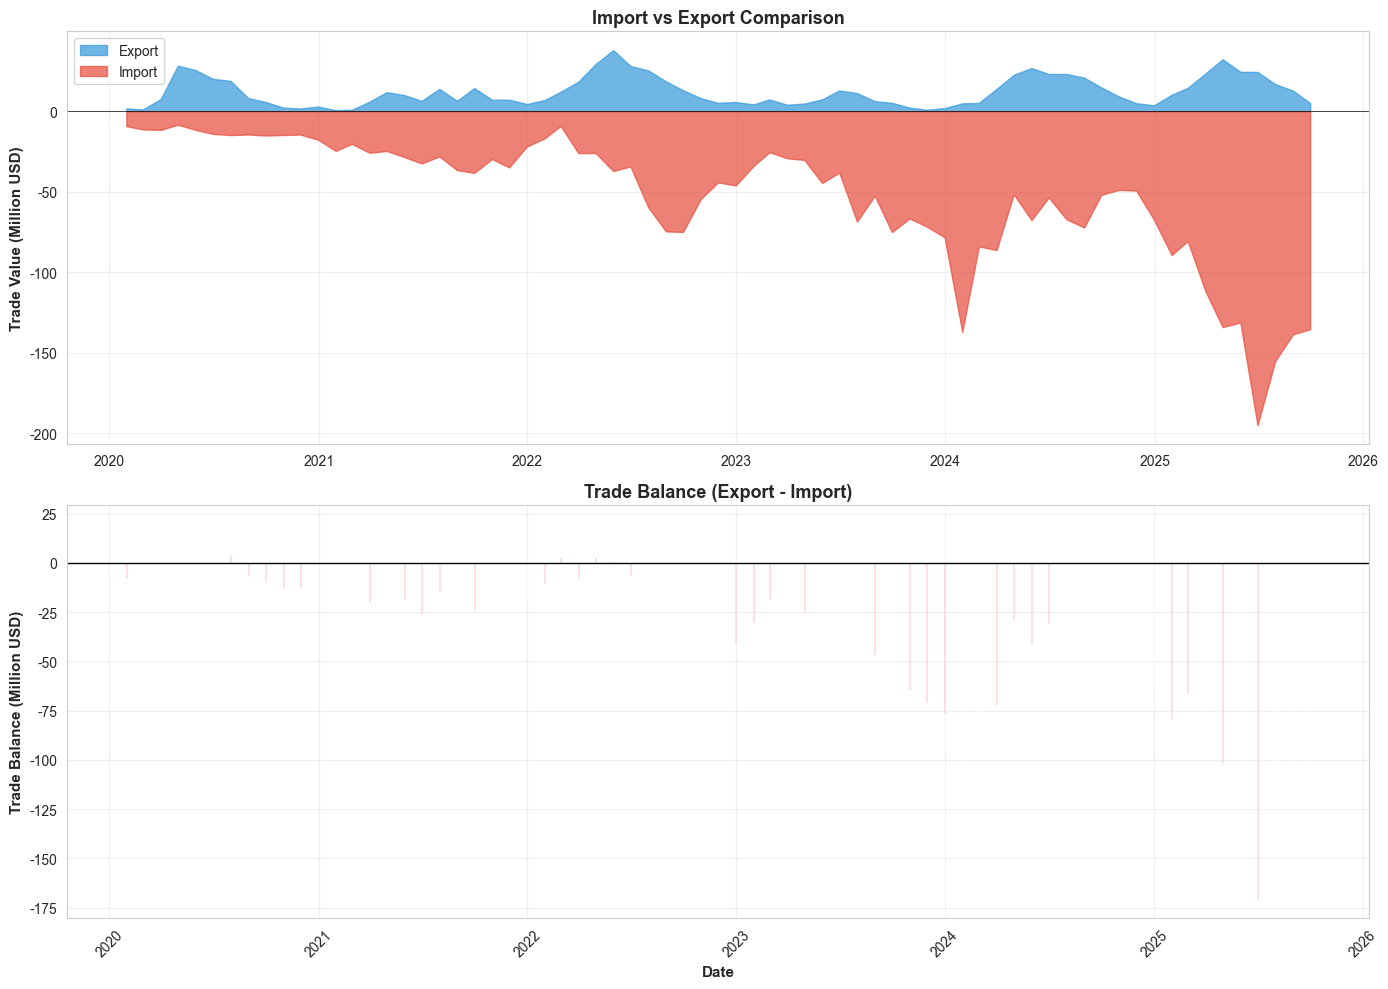

In [6]:
# 合并进出口数据计算贸易平衡
trade_balance = pd.merge(
    export_monthly.rename(columns={'US dollar_clean': 'Export'}),
    import_monthly.rename(columns={'US dollar_clean': 'Import'}),
    on='date',
    how='outer'
).fillna(0)

trade_balance['Trade Balance'] = trade_balance['Export'] - trade_balance['Import']

# 创建图表
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# 堆叠区域图
ax1.fill_between(trade_balance['date'], 0, trade_balance['Export']/1e6, 
                 alpha=0.7, label='Export', color='#3498db')
ax1.fill_between(trade_balance['date'], 0, -trade_balance['Import']/1e6, 
                 alpha=0.7, label='Import', color='#e74c3c')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax1.set_ylabel('Trade Value (Million USD)', fontsize=11, fontweight='bold')
ax1.set_title('Import vs Export Comparison', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# 贸易平衡线图
colors = ['green' if x > 0 else 'red' for x in trade_balance['Trade Balance']]
ax2.bar(trade_balance['date'], trade_balance['Trade Balance']/1e6, color=colors, alpha=0.6)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel('Date', fontsize=11, fontweight='bold')
ax2.set_ylabel('Trade Balance (Million USD)', fontsize=11, fontweight='bold')
ax2.set_title('Trade Balance (Export - Import)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()

# 保存图表
output_path = os.path.join(DASHBOARD_PATH, 'trade_balance.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"图表已保存到：{output_path}")

plt.show()

## 5. 数据汇总表格

In [7]:
# 创建汇总统计表
summary_stats = pd.DataFrame({
    'Metric': [
        'Total Import Value (Million USD)',
        'Total Export Value (Million USD)',
        'Trade Balance (Million USD)',
        'Number of Import Records',
        'Number of Export Records',
        'Number of Import Partners',
        'Number of Export Partners',
        'Number of Import Commodities',
        'Number of Export Commodities',
        'Date Range'
    ],
    'Value': [
        f"{import_data['US dollar_clean'].sum()/1e6:,.2f}",
        f"{export_data['US dollar_clean'].sum()/1e6:,.2f}",
        f"{(export_data['US dollar_clean'].sum() - import_data['US dollar_clean'].sum())/1e6:,.2f}",
        f"{len(import_data):,}",
        f"{len(export_data):,}",
        f"{import_data['Trading partner'].nunique():,}",
        f"{export_data['Trading partner'].nunique():,}",
        f"{import_data['Commodity'].nunique():,}",
        f"{export_data['Commodity'].nunique():,}",
        f"{import_data['date'].min().strftime('%Y-%m-%d')} to {import_data['date'].max().strftime('%Y-%m-%d')}"
    ]
})

print("=== 数据汇总统计 ===")
print(summary_stats.to_string(index=False))

# 保存为CSV
output_path = os.path.join(DASHBOARD_PATH, 'summary_statistics.csv')
summary_stats.to_csv(output_path, index=False)
print(f"\n汇总统计已保存到：{output_path}")

=== 数据汇总统计 ===
                          Metric                    Value
Total Import Value (Million USD)                 3,630.80
Total Export Value (Million USD)                   824.60
     Trade Balance (Million USD)                -2,806.20
        Number of Import Records                    1,783
        Number of Export Records                    1,164
       Number of Import Partners                       66
       Number of Export Partners                       67
    Number of Import Commodities                        3
    Number of Export Commodities                        2
                      Date Range 2020-01-31 to 2025-09-30

汇总统计已保存到：../dashboards/summary_statistics.csv


## 完成！

所有图表已经生成并保存到 `dashboards` 文件夹中：

1. **trade_trend_over_time.png** - 进出口趋势时间线图
2. **top_trading_partners.png** - 前10大贸易伙伴对比
3. **top_commodities.png** - 前15大商品类别饼图
4. **trade_balance.png** - 贸易平衡分析图
5. **summary_statistics.csv** - 数据汇总统计表

这些图片可以直接分享给其他人查看！

## 6. 按国家分类的单月进口数量分析（吨）

In [ ]:
# 先检查实际的贸易伙伴数据
print("=== 检查数据中的贸易伙伴 ===")
print("\n所有唯一的贸易伙伴（前20个）:")
partners = import_data['Trading partner'].unique()
print(partners[:20])
print(f"\n总共有 {len(partners)} 个贸易伙伴")

# 检查特定国家是否存在
target_countries = ['Brazil', 'Vietnam', 'Colombia', 'Uganda', 'Ethiopia', 
                   'Costa Rica', 'Honduras', 'Guatemala', 'Indonesia']
print("\n检查目标国家是否存在:")
for country in target_countries:
    exists = country in partners
    count = len(import_data[import_data['Trading partner'] == country]) if exists else 0
    print(f"  {country}: {'存在' if exists else '不存在'} ({count} 条记录)")

In [16]:
# 准备数据 - 将数量转换为吨（从kg）
def clean_quantity_value(value):
    """清理数量数据并转换为吨"""
    if pd.isna(value):
        return 0
    if isinstance(value, str):
        value = value.replace(',', '').strip()
        try:
            return float(value) / 1000  # 转换为吨
        except:
            return 0
    return float(value) / 1000  # 转换为吨

# 添加清理后的数量列（吨）
import_data['Quantity_tons'] = import_data['Quantity'].apply(clean_quantity_value)

# 提取年份和月份
import_data['year'] = import_data['date'].dt.year
import_data['month'] = import_data['date'].dt.month
import_data['year_month'] = import_data['date'].dt.to_period('M')

# 定义国家分组
def categorize_country(partner):
    """将贸易伙伴归类"""
    if pd.isna(partner):
        return 'Others'
    partner = str(partner).strip()
    
    # 中美洲国家
    central_america = ['Costa Rica', 'Honduras', 'Guatemala']
    
    if partner == 'Brazil':
        return 'Brazil'
    elif partner == 'Viet Nam':
        return 'Vietnam'
    elif partner == 'Colombia':
        return 'Colombia'
    elif partner == 'Uganda':
        return 'Uganda'
    elif partner == 'Ethiopia':
        return 'Ethiopia'
    elif partner in central_america:
        return 'Central America'
    elif partner == 'Indonesia':
        return 'Indonesia'
    else:
        return 'Others'

# 应用分类
import_data['Country_Category'] = import_data['Trading partner'].apply(categorize_country)

# 按年、月、国家分组统计
monthly_by_country = import_data.groupby(['year', 'month', 'Country_Category'])['Quantity_tons'].sum().reset_index()

# 透视表：行为年-月，列为国家
monthly_pivot = monthly_by_country.pivot_table(
    index=['year', 'month'], 
    columns='Country_Category', 
    values='Quantity_tons', 
    fill_value=0
).reset_index()

# 定义所有预期的国家列
expected_countries = ['Brazil', 'Vietnam', 'Colombia', 'Uganda', 
                     'Ethiopia', 'Central America', 'Indonesia', 'Others']

# 确保所有预期的国家列都存在，如果不存在则添加并填充0
for country in expected_countries:
    if country not in monthly_pivot.columns:
        monthly_pivot[country] = 0

# 计算总计（只使用实际存在的列）
monthly_pivot['Total'] = monthly_pivot[expected_countries].sum(axis=1)

print("单月进口数量数据准备完成！")
print(f"数据时间范围: {import_data['year'].min()} - {import_data['year'].max()}")
print(f"\n实际存在的国家列:")
print([col for col in monthly_pivot.columns if col not in ['year', 'month', 'Total']])
print(f"\n前几行数据:")
print(monthly_pivot.head(10))

单月进口数量数据准备完成！
数据时间范围: 2020.0 - 2025.0

实际存在的国家列:
['Brazil', 'Central America', 'Colombia', 'Ethiopia', 'Indonesia', 'Others', 'Uganda', 'Vietnam']

前几行数据:
Country_Category    year  month    Brazil  Central America  Colombia  \
0                 2020.0    1.0   874.945          139.259   493.155   
1                 2020.0    2.0  1318.735          341.581   393.747   
2                 2020.0    3.0   776.736         1007.916   252.846   
3                 2020.0    4.0   190.462          619.744   340.054   
4                 2020.0    5.0   492.730          487.114   469.717   
5                 2020.0    6.0   462.914         1029.485   123.176   
6                 2020.0    7.0   362.061          719.878   436.708   
7                 2020.0    8.0   507.259          354.108   342.242   
8                 2020.0    9.0   874.344          645.021   852.053   
9                 2020.0   10.0   808.249          647.703   416.307   

Country_Category  Ethiopia  Indonesia   Others   Uga

图表已保存到：../dashboards/monthly_import_by_country.png


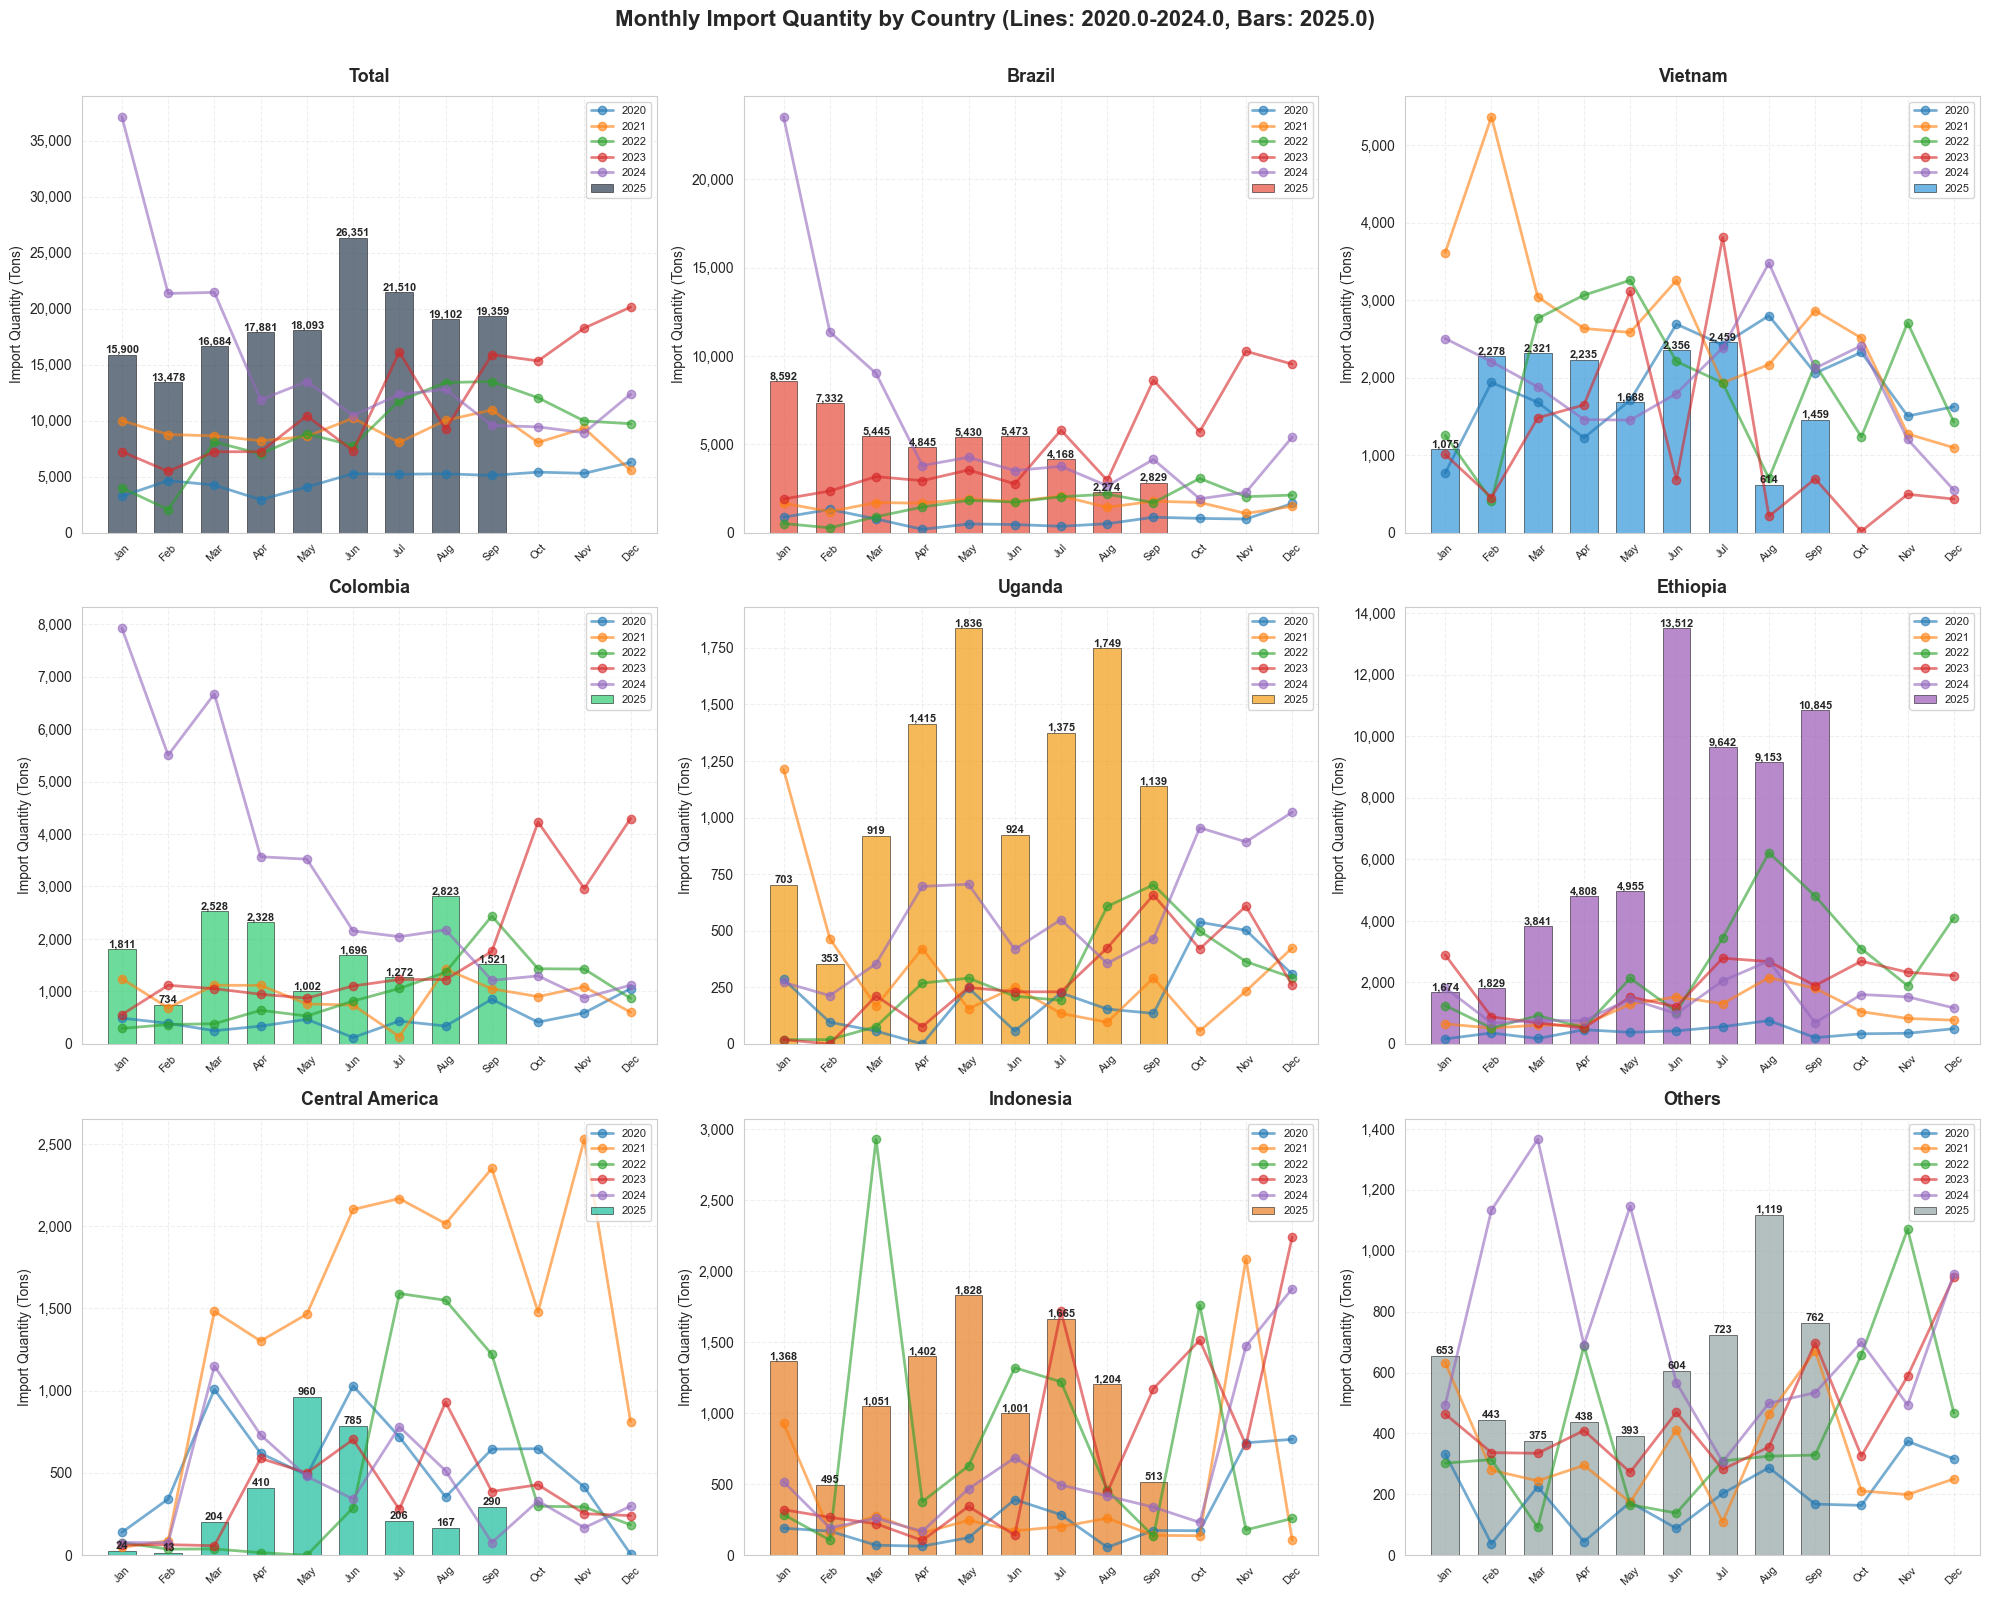

In [20]:
# 创建单月进口数量图表 - 九宫格模式
# 获取所有年份
years = sorted(monthly_pivot['year'].unique())
latest_year = max(years)
historical_years = [y for y in years if y < latest_year]

# 定义颜色方案
countries = ['Total', 'Brazil', 'Vietnam', 'Colombia', 'Uganda', 
             'Ethiopia', 'Central America', 'Indonesia', 'Others']
colors = ['#2c3e50', '#e74c3c', '#3498db', '#2ecc71', '#f39c12', 
          '#9b59b6', '#1abc9c', '#e67e22', '#95a5a6']
color_map = dict(zip(countries, colors))

# 创建3x3的子图
fig, axes = plt.subplots(3, 3, figsize=(20, 16))
axes = axes.flatten()

# 为每个国家创建一个子图
for idx, country in enumerate(countries):
    ax = axes[idx]
    
    if country not in monthly_pivot.columns:
        ax.text(0.5, 0.5, f'No data for {country}', 
               ha='center', va='center', fontsize=12)
        ax.set_title(country, fontsize=13, fontweight='bold', pad=10)
        continue
    
    # 绘制历史年份的线图
    for year in historical_years:
        year_data = monthly_pivot[monthly_pivot['year'] == year].sort_values('month')
        if country in year_data.columns:
            ax.plot(year_data['month'], year_data[country], 
                   marker='o', linewidth=2, alpha=0.6,
                   label=f'{int(year)}')
    
    # 绘制最新年份的柱状图
    latest_data = monthly_pivot[monthly_pivot['year'] == latest_year].sort_values('month')
    if country in latest_data.columns and len(latest_data) > 0:
        bars = ax.bar(latest_data['month'], latest_data[country], 
                     width=0.6, label=f'{int(latest_year)}',
                     color=color_map[country], alpha=0.7, edgecolor='black', linewidth=0.5)
        
        # 在柱子上标注数值（只标注非零值，添加千分位分隔符）
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:,.0f}',
                       ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    # 设置子图属性
    ax.set_ylabel('Import Quantity (Tons)', fontsize=10)
    ax.set_title(country, fontsize=13, fontweight='bold', pad=10)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                        'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], 
                       fontsize=8, rotation=45)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # 设置y轴从0开始，并添加千分位格式
    ax.set_ylim(bottom=0)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# 添加总标题
fig.suptitle(f'Monthly Import Quantity by Country (Lines: {historical_years[0]}-{historical_years[-1]}, Bars: {latest_year})', 
            fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.99])

# 保存图表
output_path = os.path.join(DASHBOARD_PATH, 'monthly_import_by_country.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"图表已保存到：{output_path}")

plt.show()

## 7. 按国家分类的累计进口数量分析（吨）

In [ ]:
# 计算每年的累计进口量
cumulative_data = []

for year in years:
    year_data = monthly_pivot[monthly_pivot['year'] == year].sort_values('month').copy()
    
    # 为每个国家计算累计值
    for country in countries:
        if country in year_data.columns:
            year_data[f'{country}_cumsum'] = year_data[country].cumsum()
    
    cumulative_data.append(year_data)

# 合并所有年份的累计数据
cumulative_pivot = pd.concat(cumulative_data, ignore_index=True)

print("累计进口数量数据准备完成！")
print(f"\n前几行数据:")
print(cumulative_pivot[['year', 'month', 'Total_cumsum', 'Brazil_cumsum', 'Vietnam_cumsum']].head(10))

In [ ]:
# 创建累计进口数量图表
fig, ax = plt.subplots(figsize=(16, 8))

# 绘制历史年份的线图
for year in historical_years:
    year_data = cumulative_pivot[cumulative_pivot['year'] == year].sort_values('month')
    
    for country in countries:
        cumsum_col = f'{country}_cumsum'
        if cumsum_col in year_data.columns:
            ax.plot(year_data['month'], year_data[cumsum_col], 
                   marker='o', linewidth=2, alpha=0.7,
                   color=color_map[country],
                   label=f'{country} ({year})' if year == historical_years[0] else '')

# 绘制最新年份的柱状图
latest_cumulative = cumulative_pivot[cumulative_pivot['year'] == latest_year].sort_values('month')

if len(latest_cumulative) > 0:
    # 为每个月创建分组柱状图
    x = np.arange(len(latest_cumulative))
    width = 0.08
    
    for i, country in enumerate(countries):
        cumsum_col = f'{country}_cumsum'
        if cumsum_col in latest_cumulative.columns:
            offset = (i - len(countries)/2) * width
            bars = ax.bar(latest_cumulative['month'] + offset, latest_cumulative[cumsum_col], 
                         width, label=f'{country} ({latest_year})',
                         color=color_map[country], alpha=0.8)
            
            # 在柱子上标注数值
            for bar in bars:
                height = bar.get_height()
                if height > 0:
                    ax.text(bar.get_x() + bar.get_width()/2., height,
                           f'{height:.0f}',
                           ha='center', va='bottom', fontsize=7, rotation=0)

ax.set_xlabel('Month', fontsize=12, fontweight='bold')
ax.set_ylabel('Cumulative Import Quantity (Tons)', fontsize=12, fontweight='bold')
ax.set_title(f'Cumulative Import Quantity by Country (Jan-Dec) (Lines: {historical_years[0]}-{historical_years[-1]}, Bars: {latest_year})', 
            fontsize=14, fontweight='bold')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()

# 保存图表
output_path = os.path.join(DASHBOARD_PATH, 'cumulative_import_by_country.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"图表已保存到：{output_path}")

plt.show()

In [ ]:
# 导出详细数据表到CSV
# 单月数据
monthly_export = monthly_pivot.copy()
monthly_export['year_month'] = monthly_export['year'].astype(str) + '-' + monthly_export['month'].astype(str).str.zfill(2)
monthly_export = monthly_export[['year_month', 'year', 'month'] + countries]
monthly_export.to_csv(os.path.join(DASHBOARD_PATH, 'monthly_import_by_country.csv'), index=False)

# 累计数据
cumulative_export = cumulative_pivot.copy()
cumulative_export['year_month'] = cumulative_export['year'].astype(str) + '-' + cumulative_export['month'].astype(str).str.zfill(2)
cumsum_cols = [f'{c}_cumsum' for c in countries if f'{c}_cumsum' in cumulative_export.columns]
cumulative_export = cumulative_export[['year_month', 'year', 'month'] + cumsum_cols]
cumulative_export.to_csv(os.path.join(DASHBOARD_PATH, 'cumulative_import_by_country.csv'), index=False)

print("数据表已导出到CSV文件：")
print("- monthly_import_by_country.csv")
print("- cumulative_import_by_country.csv")